## Set up Gurobipy
---

In [1]:
# First you can check, whether the required packages are already installed
# (if not, you'll receive a warning)
%pip show gurobipy
%pip show matplotlib
%pip show numpy
%pip show pandas

Name: gurobipy
Version: 13.0.1
Summary: Python interface to Gurobi
Home-page: https://www.gurobi.com
Author: Gurobi Optimization, LLC
Author-email: 
License: Proprietary
Location: /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages
Requires: 
Required-by: 
Note: you may need to restart the kernel to use updated packages.
Name: matplotlib
Version: 3.10.8
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive, royalty-free, world-wide license
 t

In [2]:
#%pip install gurobipy
#%pip install matplotlib
#%pip install numpy
#%pip install pandas

Import them into this notebook

In [3]:
import gurobipy as gp 
from gurobipy import GRB
from gurobipy import *  # imports everything from gurobipy without alias
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Budget-Constrained SALBP-2 with Human, Cobot & Humanoid
-----------------------------------------

*Budget-constrained extension of SALBP-2: each task can be performed by a **Human**, **Cobot** or **Humanoid** resource with a resource-dependent time and cost. We minimize the cycle time $C$ under a hard investment budget $B$.*

**Idea (presentation #2):** Each task can be performed by a different **resource type** $r \in \{$Human, Cobot, Humanoid$\}$ with a resource-dependent processing time $t_{ir}$ and cost. We minimize the cycle time $C$ subject to a hard **investment budget** $B$.

### New sets / parameters
$r \in \{$Human, Cobot, Humanoid$\}$ — resource types &nbsp;&nbsp; $t_{ir}$ — time of task $i$ with resource $r$ &nbsp;&nbsp; $H$ — horizon (h/yr) &nbsp;&nbsp; $B$ — budget &nbsp;&nbsp; $K_r = \text{invest}_r + \text{operating}_r \cdot H$

### New decision variables
$Y_{kr}=1$ if station $k$ is equipped with resource $r$ &nbsp;&nbsp; $S_{ikr}=1$ if task $i$ runs at station $k$ using resource $r$

### Objective &amp; constraints
$\min\ C$
1. $\sum_{k}\sum_{r} S_{ikr}=1\ \ \forall i$ &nbsp; (each task once)
2. $\sum_{k}\sum_{r} S_{ikr}\,k \le \sum_{k}\sum_{r} S_{jkr}\,k\ \ \forall (i,j)\in P$ &nbsp; (precedence)
3. $\sum_{i}\sum_{r} S_{ikr}\,t_{ir} \le C\ \ \forall k$ &nbsp; (cycle time)
4. $\sum_{r} Y_{kr}=1\ \ \forall k$ &nbsp; (one resource per station)
5. $S_{ikr} \le Y_{kr}\ \ \forall i,k,r$ &nbsp; (coupling)
6. $\sum_{k}\sum_{r} K_r Y_{kr} \le B$ &nbsp; (budget)


### Sets
---

In [4]:
Operations = [1,2,3,4,5,6,7,8,9]
Stations   = [1,2,3,4,5,6]
Resources  = ["Human", "Cobot", "Industrial", "Humanoid"]   # 4 resource types r

N, M, R = len(Operations), len(Stations), len(Resources)

# Realistic simplified car final-assembly operations (one line segment)
OpNames = [
    "Underbody bolting",         # 1
    "Suspension & wheels",       # 2
    "Windshield bonding & set",  # 3
    "Wiring harness routing",    # 4
    "Cockpit / dashboard",       # 5
    "Seat installation",         # 6
    "Interior trim & clips",     # 7
    "HV battery & fluids",       # 8
    "Final inspection",          # 9
]

# Precedence (i before j): assembly sequence, final inspection last
PrecRelations = [[1,2],[1,8],[4,5],[4,7],[5,6],[3,6],[8,9],[6,9],[7,9],[2,9],[5,9]]

### Processing times & eligibility  (realistic car final-assembly scenario)
Each operation can be performed by up to four resource types. **Cobots** collaborate with humans (light, precise, safe) but have limited payload and no fine dexterity. **Industrial robots** work standalone in a safety cell (fast, heavy, precise on rigid repetitive tasks) but cannot handle deformable parts, judgement or human-shared space. **Humanoids** are the most flexible machines. **Humans** are best on delicate/deformable parts and are the only resource for final inspection.

`t[i][r]` is the processing time in minutes; a value of `BIG` (99) marks a combination that is not used, and the eligibility matrix `elig[i][r]` forbids it explicitly. Columns follow `Resources = [Human, Cobot, Industrial, Humanoid]`.

In [5]:
BIG = 99.0   # sentinel time for ineligible combinations (also forbidden by elig)

#        Human  Cobot  Industrial  Humanoid          # minutes
t = [
    [ 5.5,  4.5,  3.5,  4.0],   # 1 Underbody bolting      (rigid, overhead, repetitive)
    [ 7.4,  BIG,  4.0,  5.0],   # 2 Suspension & wheels    (high payload -> not cobot)
    [ 6.0,  4.5,  3.5,  4.0],   # 3 Windshield bonding     (precise bead + heavy glass)
    [ 4.0,  BIG,  BIG,  5.0],   # 4 Wiring harness         (deformable, fine -> human/humanoid)
    [ 6.5,  BIG,  BIG,  5.0],   # 5 Cockpit / dashboard    (bulky, confined reach)
    [ 5.0,  BIG,  3.5,  4.0],   # 6 Seat installation      (heavy, repetitive)
    [ 4.5,  BIG,  BIG,  5.5],   # 7 Interior trim & clips  (fiddly, deformable clips)
    [ 4.5,  4.0,  3.5,  3.8],   # 8 HV battery & fluids    (safety + precise, rigid)
    [ 3.0,  BIG,  BIG,  BIG],   # 9 Final inspection       (judgement -> human only)
]

# Eligibility elig[i][r] = 1 if resource r can perform operation i, else 0
#        Human  Cobot  Industrial  Humanoid
elig = [
    [ 1,  1,  1,  1],   # 1 Underbody bolting
    [ 1,  0,  1,  1],   # 2 Suspension & wheels    (cobot payload too low)
    [ 1,  1,  1,  1],   # 3 Windshield bonding
    [ 1,  0,  0,  1],   # 4 Wiring harness         (no dexterity for cobot/industrial)
    [ 1,  0,  0,  1],   # 5 Cockpit / dashboard    (reach / flexibility)
    [ 1,  0,  1,  1],   # 6 Seat installation      (cobot payload too low)
    [ 1,  0,  0,  1],   # 7 Interior trim & clips  (deformable clips)
    [ 1,  1,  1,  1],   # 8 HV battery & fluids
    [ 1,  0,  0,  0],   # 9 Final inspection       (human judgement only)
]

assert len(t) == N and all(len(row) == R for row in t), "t must be N x R."
assert len(elig) == N and all(len(row) == R for row in elig), "elig must be N x R."

### Cost parameters & budget  (realistic 2025/26 figures)
$K_r = \text{invest}_r + \text{operating}_r \cdot H$

In [6]:
# Cost parameters (every number traced to a source; see Quellen_Datengrundlage.xlsx)
H = 2000                                                        # planning horizon (h/year, ~1 shift)

# --- Acquisition / investment [EUR] (sourced) ---
investment = {"Human": 0, "Cobot": 75000, "Industrial": 120000, "Humanoid": 200000}
#   Cobot: cost model IJAMT 2023 + market;  Humanoid: Goldman Sachs (30-150k$ range)

# --- Operating cost per hour is DERIVED, not assumed: ---
#   operating = wage(human) + energy(power x elec_price) + maintenance(maint_rate x invest / H)
wage       = {"Human": 45, "Cobot": 0, "Industrial": 0, "Humanoid": 0}          # Human: Eurostat lc_lci_lev (DE ~45)
power_kW   = {"Human": 0.0, "Cobot": 0.35, "Industrial": 0.7, "Humanoid": 1.0}    # Cobot: UR10e datasheet; Humanoid: estimate
elec_price = 0.20                                              # EUR/kWh industrial, Eurostat nrg_pc_205 (DE 2024)
maint_rate = 0.10                                             # 10%/yr of investment (robot TCO literature, 5-10%)

operating = {r: wage[r] + power_kW[r]*elec_price + maint_rate*investment[r]/H for r in Resources}
# -> Human 45.0 ; Cobot ~2.82 ; Humanoid ~4.70  EUR/h

# K(r) = investment + operating * H   (first-year total cost of ownership)
#  -> Cobot ~60,640  <  Human 90,000  <  Humanoid ~99,400  EUR
Kcost = [investment[r] + operating[r]*H for r in Resources]
print("operating(EUR/h):", {r: round(operating[r],2) for r in Resources})
print("K(r):", dict(zip(Resources, [round(k) for k in Kcost])))

B = 480000        # annual resourcing budget EUR  (the knob to sweep for the frontier)

operating(EUR/h): {'Human': 45.0, 'Cobot': 3.82, 'Industrial': 6.14, 'Humanoid': 10.2}
K(r): {'Human': 90000, 'Cobot': 82640, 'Industrial': 132280, 'Humanoid': 220400}


### Model as a function `build_and_solve(B)`
---
Wrapping the model in a function lets us re-solve for many budget levels to trace the time-cost frontier.

In [7]:
def build_and_solve(B, silent=True):
    m = gp.Model("BudgetSALBP2")
    m.setParam("OutputFlag", 0)
    m.setParam("MIPGap", 0)

    # --- decision variables ---
    S = m.addVars(N, M, R, vtype=GRB.BINARY, name="S")   # task i at station k on resource r
    Y = m.addVars(M, R,    vtype=GRB.BINARY, name="Y")   # station k equipped with resource r
    C = m.addVar(lb=0, name="C")
    symBreak = m.addVar(lb=0, name="symBreak")

    # --- objective: minimize cycle time ---
    m.setObjective(C + symBreak, GRB.MINIMIZE)

    # (1) each task assigned exactly once (any station, any resource)
    m.addConstrs((quicksum(S[i,k,r] for k in range(M) for r in range(R)) == 1
                  for i in range(N)), name="assign")

    # (2) precedence (via station index)
    m.addConstrs((quicksum(S[i,k,r]*k for k in range(M) for r in range(R))
                  <= quicksum(S[j,k,r]*k for k in range(M) for r in range(R))
                  for i in range(N) for j in range(N) if [i+1,j+1] in PrecRelations),
                 name="prec")

    # (3) cycle time per station (resource-dependent time)
    m.addConstrs((quicksum(S[i,k,r]*t[i][r] for i in range(N) for r in range(R)) <= C
                  for k in range(M)), name="cycle")

    # (4) exactly one resource type per station
    m.addConstrs((quicksum(Y[k,r] for r in range(R)) == 1 for k in range(M)), name="oneRes")

    # (5) coupling: a task uses resource r only if the station is equipped with it
    m.addConstrs((S[i,k,r] <= Y[k,r]
                  for i in range(N) for k in range(M) for r in range(R)), name="couple")

    # (6) budget
    m.addConstr(quicksum(Kcost[r]*Y[k,r] for k in range(M) for r in range(R)) <= B, name="budget")

    # check eligibilty
    m.addConstrs(
        S[i,k,r] <= elig[i][r]
        for i in range(N)
        for k in range(M)
        for r in range(R)
    )

    # symmetry breaking (adapted to 3D)
    m.addConstr(symBreak >= quicksum(S[i,k,r]*k*(0.1**(i+1))
                for i in range(N) for k in range(M) for r in range(R)), name="sym")

    m.optimize()
    if m.status != GRB.OPTIMAL:
        return None
    cost = sum(Kcost[r]*round(Y[k,r].X) for k in range(M) for r in range(R))
    return m, S, Y, C, cost

### Single run & solution
---

In [8]:
res = build_and_solve(B)
if res is None:
    print("No solution (budget too small?)")
else:
    m, S, Y, C, cost = res
    print(f"Cycle Time C: {C.x:.2f}   |   used budget: {cost} EUR  (B={B})")
    for k in range(M):
        rk  = next(Resources[r] for r in range(R) if Y[k,r].X > 0.5)
        ops = [i+1 for i in range(N) for r in range(R) if S[i,k,r].X > 0.5]
        print(f"  Station {k+1} [{rk:8}] -> operations {ops}")

Set parameter Username
Set parameter LicenseID to value 2814445
Academic license - for non-commercial use only - expires 2027-04-28
No solution (budget too small?)


### Time-Cost Frontier (sweep the budget)
---
This is the central result of the study (cf. Paper A): how much cycle time is gained per extra EUR of budget.

B=  372000:  infeasible
B=  410000:  infeasible
B=  450000:  infeasible
B=  500000:  infeasible
B=  550000:  C=9.00  used=540000.0
B=  600000:  C=9.00  used=540000.0


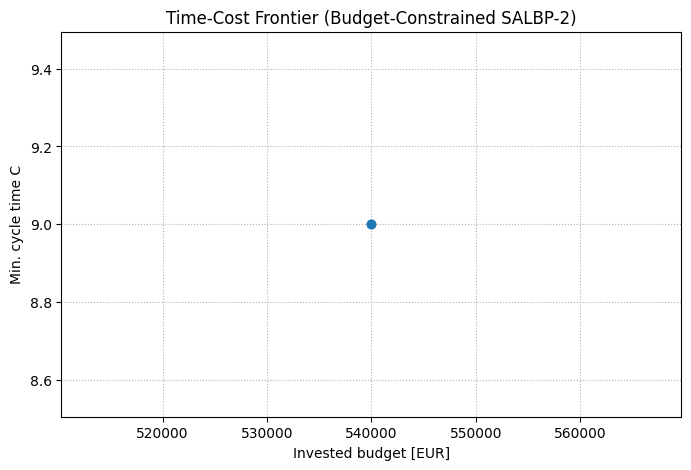

In [9]:
# Feasibility depends on eligibility + one-resource-per-station (==1 pays for all 6 stations).
# If a run is infeasible, raise the budget or switch constraint (4) to <= 1 (empty stations become free).
budgets = [520000, 620000, 740000, 880000, 1050000, 1200000]
front = []
for Bi in budgets:
    r = build_and_solve(Bi)
    if r:
        front.append((r[4], r[3].x))          # (used budget, C)
    print(f"B={Bi:>8}:  " + (f"C={r[3].x:.2f}  used={r[4]}" if r else "infeasible"))

if front:
    xs, ys = zip(*front)
    plt.figure(figsize=(8,5))
    plt.step(xs, ys, where="post", marker="o")
    plt.xlabel("Invested budget [EUR]"); plt.ylabel("Min. cycle time C")
    plt.title("Time-Cost Frontier (Budget-Constrained SALBP-2)")
    plt.grid(True, linestyle=":"); plt.show()

### Station utilization by resource
---

In [10]:
res = build_and_solve(B)
if res:
    m, S, Y, C, cost = res
    rescol = {"Human":"#4C72B0", "Cobot":"#DD8452", "Industrial":"#C44E52", "Humanoid":"#55A868"}
    fig, ax = plt.subplots(figsize=(10,6)); bottoms = {k:0.0 for k in range(M)}
    for k in range(M):
        rk = next(Resources[r] for r in range(R) if Y[k,r].X > 0.5)
        for i in range(N):
            for r in range(R):
                if S[i,k,r].X > 0.5:
                    d = t[i][r]
                    ax.bar(k, d, bottom=bottoms[k], width=0.6,
                           color=rescol[rk], edgecolor='black')
                    ax.text(k, bottoms[k]+d/2, f'Op {i+1}', ha='center', va='center',
                            color='white', fontweight='bold')
                    bottoms[k] += d
        ax.text(k, -0.4, rk, ha='center', va='top', fontsize=9, fontweight='bold')
    ax.axhline(C.x, color='red', ls='--', lw=2, label=f'C = {C.x:.2f}')
    ax.set_xticks(range(M)); ax.set_xticklabels([f'St {k+1}' for k in range(M)])
    ax.set_xlabel('Station'); ax.set_ylabel('Utilization'); ax.legend()
    ax.set_title('Station utilization by resource'); plt.tight_layout(); plt.show()
else:
    print("No solution to visualize.")

No solution to visualize.


### Notes & data sources
**Cost basis (2025/26):**
- Human: German labour cost ~45 EUR/h (Eurostat lc_lci_lev), no capital cost.
- Cobot: ~55,000 EUR (cost model IJAMT 2023 + market); operating derived = energy (UR10e 350W x 0.20 EUR/kWh, Eurostat) + maintenance (10% of capex/yr, robot TCO literature).
- Humanoid: ~90,000 EUR (Goldman Sachs, 30-150k$ range); operating derived = energy + maintenance (10% of capex/yr). Only the humanoid power draw (~1 kW) is a rough estimate (minor: ~0.2 EUR/h).
- Resulting annual K(r): **Cobot ~60.6k < Human 90k < Humanoid ~99.4k EUR** -> a real price gradient.

**Built-in trade-off:** the cheap cobot is slow on delicate tasks; the fast humanoid is the most
expensive -> more budget buys speed, so the time-cost frontier should now slope downward.

**Modelling switches:**
- Constraint (4) `== 1` forces every station to be equipped (and paid). Use `<= 1` to allow free empty stations.
- Capex is counted in full in year 1. For an annualized view, divide `investment` by a useful life (e.g. 8 years).
- Make a resource infeasible for a task by setting a very large time or fixing `S[i,k,r]=0`.

> I could not run Gurobi in this environment, so please execute the notebook once and check the
> frontier shape; if it is still flat, tighten the instance (fewer stations) or widen the time gap on the bottleneck tasks.
